# Test training 

In [1]:
# Imports 
%load_ext autoreload
%autoreload 2

import torch 
from torch.utils.data import DataLoader

import random
import numpy as np 
from matplotlib import pyplot as plt

from safe_neural_operators.data_collection import load_hjr_solution, \
    get_dynamics_model_given_disturbance_fn, \
    get_disturbance_function_sincos
from safe_neural_operators.hjr_dataset import HJRDataset

import sys 
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project")

from deepreach.dynamics import dynamics 
from deepreach.dynamics import dynamics_hjr
from deepreach.utils.comparisons import GroundTruthHJSolution

# NeuralOp Imports 
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.utils import count_model_params
from neuralop import LpLoss, H1Loss


In [2]:
# Create dataset 
root_dir = "/media/jingpei/DATA/fno_gp_data"
samples_for_train = 90
samples_for_test = 10 
datapoints_per_sample = 100
batch_size = 32
pre_sample_dataset = True 
encode_output = False 
encode_input = True 
encoding = "channel-wise"


dataset = HJRDataset(root_dir=root_dir, 
                 samples_for_train=samples_for_train, 
                 samples_for_test=samples_for_test, 
                 datapoints_per_sample=datapoints_per_sample,

                 batch_size=batch_size, 
                 pre_sample_dataset=pre_sample_dataset, 

                 encode_output=encode_output,
                 encode_input=encode_input,
                 encoding=encoding)

/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  grid_states = torch.load(grid_state

In [3]:
print(len(dataset.train_db))
print(dataset.train_db[200]['x'].shape)
print(dataset.train_db[200]['y'].shape)

9000
torch.Size([3, 41, 41])
torch.Size([1, 41, 41])


In [4]:
# Data Loaders
batch_size = 32

train_loader = DataLoader(dataset.train_db, 
                          batch_size=batch_size, 
                          num_workers=1, 
                          pin_memory=True,
                          persistent_workers=False)

test_db = dataset.test_dbs[0]
test_loader = DataLoader(test_db,
                         batch_size=batch_size,
                         shuffle=False,
                         num_workers=1,
                         pin_memory=True,
                         persistent_workers=False)

data_processor = dataset.data_processor

In [6]:
# Model 
n_modes = (16, 16)
in_channels = 3
out_channels = 1
hidden_channels = 64
projection_channel_ratio = 2
factorization = 'tucker'  
rank = 0.42

model = FNO(n_modes=n_modes, 
            in_channels=in_channels,
            out_channels=out_channels,
            hidden_channels=hidden_channels,
            projection_channel_ratio=projection_channel_ratio,
            factorization=factorization, 
            rank=rank)

n_params = count_model_params(model)
print(f'\nOur model has {n_params} parameters.')


Our model has 1999057 parameters.


In [7]:
#Create the optimizer
optimizer = AdamW(model.parameters(), 
                                lr=8e-3, 
                                weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)


In [8]:
# Creating the losses
l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses={'h1': h1loss, 'l2': l2loss}

In [9]:
# Print Logging 
print('\n### MODEL ###\n', model)
print('\n### OPTIMIZER ###\n', optimizer)
print('\n### SCHEDULER ###\n', scheduler)
print('\n### LOSSES ###')
print(f'\n * Train: {train_loss}')
print(f'\n * Test: {eval_losses}')


### MODEL ###
 FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): TuckerTensor(shape=(64, 64, 16, 9), rank=(51, 51, 13, 7))
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
          (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(5, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(1

In [11]:
# Create the trainer
device = 'cuda:0'
save_dir = "./NIKHIL_SAFETYFUNC_TEST_checkpoints"

trainer = Trainer(model=model, n_epochs=10,
                  device=device,
                  data_processor=data_processor,
                  wandb_log=False,
                  eval_interval=3,
                  use_distributed=False,
                  verbose=True)


trainer.train(train_loader=train_loader,
              test_loaders={},
              optimizer=optimizer,
              scheduler=scheduler, 
              regularizer=False, 
              training_loss=train_loss, 
              save_every=1,
              save_dir=save_dir)

Training on 9000 samples
Testing on [] samples         on resolutions [].
Raw outputs of shape torch.Size([32, 1, 41, 41])
[0] time=6.11, avg_loss=0.3785, train_err=12.0792
Eval: 
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[3] time=4.92, avg_loss=0.1826, train_err=5.8291
Eval: 
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[6] time=5.04, avg_loss=0.1412, train_err=4.5067
Eval: 
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[Rank 0]: saved training state to ./NIKHIL_SAFETYFUNC_TEST_checkpoints
[9] time=4.98, avg_loss=0.1183, train_err=3.7762
Eval: 
[Rank 0]: sav

{'train_err': 3.776161219211335,
 'avg_loss': 0.11831971820195517,
 'avg_lasso_loss': None,
 'epoch_train_time': 4.981880348641425}

In [29]:
# Plot results 
test_idx = 25
test_input = test_db[test_idx]['x'].unsqueeze(0).to(device)
test_output = test_db[test_idx]['y'].unsqueeze(0).to(device)

pred_output = model.forward(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Predicted shape: {pred_output.shape}")

Input shape: torch.Size([1, 3, 41, 41])
Output shape: torch.Size([1, 1, 41, 41])
Predicted shape: torch.Size([1, 1, 41, 41])


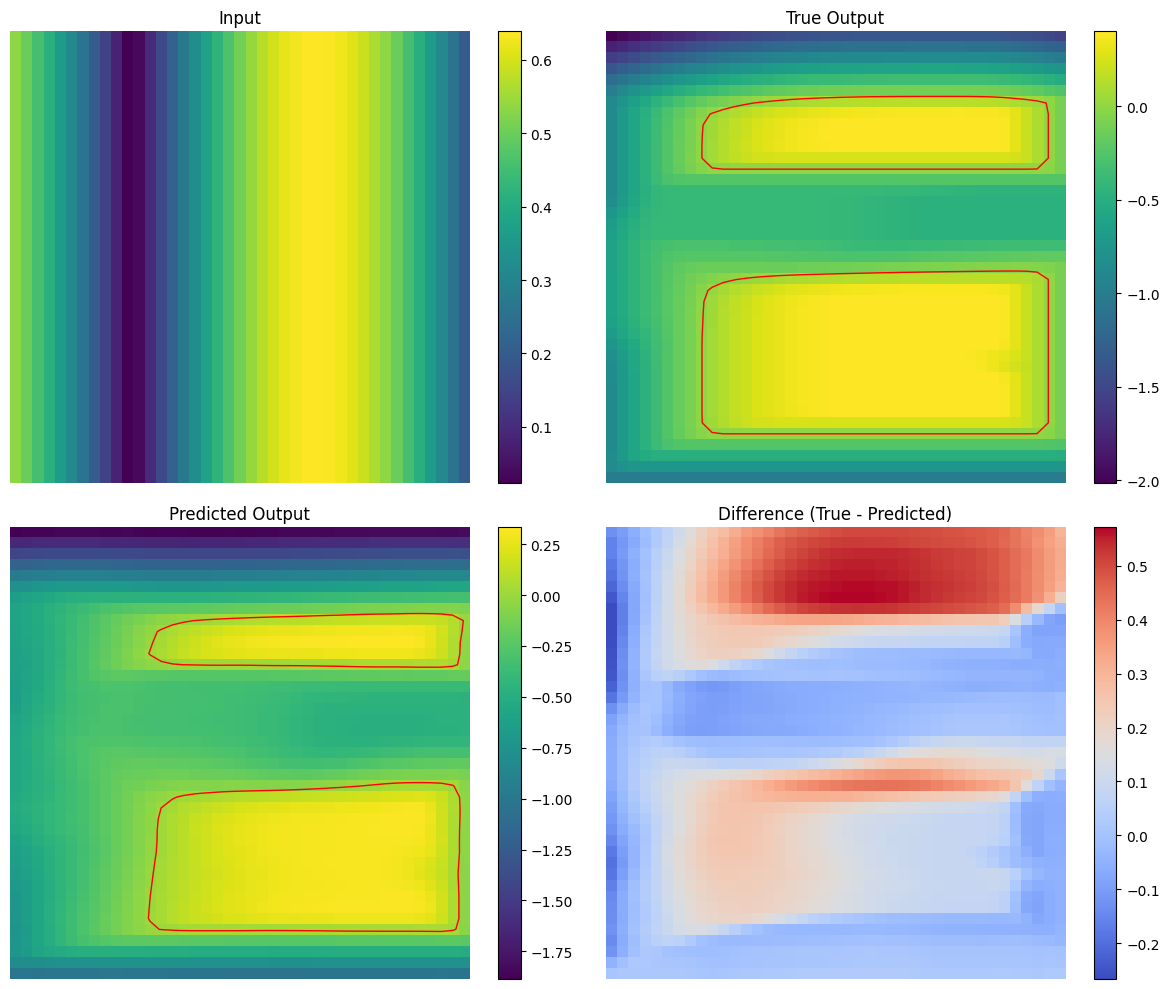

In [31]:
# Plot results 
# Convert tensors to CPU and detach for plotting
plot_test_input = test_input.cpu().detach().numpy()[0, 0, :, :]
plot_test_output = test_output.cpu().detach().numpy()[0, 0, :, :]
plot_predicted_output = pred_output.cpu().detach().numpy()[0, 0, :, :]
difference = plot_test_output - plot_predicted_output

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Input
im_input = axs[0, 0].imshow(plot_test_input, cmap='viridis', aspect='auto')
axs[0, 0].set_title("Input")
axs[0, 0].axis('off')
fig.colorbar(im_input, ax=axs[0, 0], orientation='vertical')

# True Output
axs[0, 1].imshow(plot_test_output, cmap='viridis', aspect='auto')
axs[0, 1].set_title("True Output")
axs[0, 1].axis('off')
# True Output with contour
contour_true = axs[0, 1].contour(plot_test_output, levels=[0], colors='red', linewidths=1)
axs[0, 1].set_title("True Output")
axs[0, 1].axis('off')
fig.colorbar(axs[0, 1].images[0], ax=axs[0, 1], orientation='vertical')

# Predicted Output with contour
axs[1, 0].imshow(plot_predicted_output, cmap='viridis', aspect='auto')
contour_pred = axs[1, 0].contour(plot_predicted_output, levels=[0], colors='red', linewidths=1)
axs[1, 0].set_title("Predicted Output")
axs[1, 0].axis('off')
fig.colorbar(axs[1, 0].images[0], ax=axs[1, 0], orientation='vertical')

# Difference
im = axs[1, 1].imshow(difference, cmap='coolwarm', aspect='auto')
axs[1, 1].set_title("Difference (True - Predicted)")
axs[1, 1].axis('off')
fig.colorbar(im, ax=axs[1, 1], orientation='vertical')

plt.tight_layout()
plt.show()